In [1]:
from jax import jit, random, vmap
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import config
import jax
import sys
from functools import partial

sys.path.append("../src")

jax.config.update("jax_platform_name", "cpu")

config.update("jax_enable_x64", True)

In [2]:
from configuration.rte2d_settings_ex5_oerfm2 import get_config
from constraints.continuous2d_oe_2_copy import (
    OddEvenDecompositionPointwiseBoundaryConstraint2D as BC,
    OddEvenDecompositionPointwiseInteriorConstraint2D as EQ,
)
from geometry.meshxd_ds import UniformMeshXYV
from modules.generator_2 import Sample2D
from modules.solution_2 import OddEvenDecompositionConstructor2D
from solver.least_square import solve
from utils.integrate import leggauss

In [3]:
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
strides = rte_config.mesh["strides"]
kn = rte_config.model.knudsen_number
coeff_fns = rte_config.model.coeff
source_fn = rte_config.model.source
Jn = rte_config.model.Jn
num_unknowns = rte_config.model.num_unknowns["j/r"]
scale = rte_config.model.scale
activation = rte_config.model.activation
regularizer = rte_config.model.regularizer
mode = rte_config.model.sample_mode
collocation_sizes = rte_config.model.collocation_sizes
bdy_value = rte_config.model.bdy_cond
key_num = rte_config.model.random_seed
rng_key = random.key(key_num)
num_quads = rte_config.model.num_quads
mesh_j = UniformMeshXYV(domain=domain, strides=strides)
mesh_r = UniformMeshXYV(domain=domain, strides=strides)

In [4]:
rte = EQ(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    num_quads=num_quads,
    kn=kn,
    activation=activation,
    coeff_fns=coeff_fns,
)
bc = BC(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
)

In [5]:
dummy_x, dummy_y, dummy_theta = jnp.split(jnp.array([0.5, 0.5, 0.0]), 3, axis=0)
params = {}
eq_instance = rte.apply(params, dummy_x, dummy_y, dummy_theta)
bc_instance = bc.apply(params, dummy_x, dummy_y, dummy_theta)

In [6]:
eq_instance.shape, bc_instance.shape

((3, 1024), (1024,))

In [7]:
def eq_fn(x, y, theta):
    return partial(rte.apply, params)(x, y, theta)


def bc_fn(x, y, theta):
    return partial(bc.apply, params)(x, y, theta)


def rhs_fn(x, y, theta):
    # 与EQ一致，采用[0, π]平均并除以π
    quadratures = leggauss(num_quads, (0, jnp.pi))
    pts, ws = quadratures

    def q_sym1(x, y, theta):
        return 0.5 * (source_fn(x, y, theta) + source_fn(x, y, theta + jnp.pi))

    def q_asym1(x, y, theta):
        return 0.5 * (source_fn(x, y, theta) - source_fn(x, y, theta + jnp.pi))

    # 角度积分，算平均源项（与EQ一致）
    weighted_sum1 = vmap(q_sym1, [None, None, 0])(x, y, pts) * ws
    avg_q1 = jnp.sum(weighted_sum1) / jnp.pi

    rhs = jnp.stack(
        [
            avg_q1.squeeze(),
            kn**2 * (q_sym1(x, y, theta) - avg_q1).squeeze(),
            kn * q_asym1(x, y, theta).squeeze(),
        ],
        axis=0,
    )
    return rhs


vmap_eq_fn, vmap_bc_fn, vmap_rhs_fn = (
    jit(vmap(eq_fn)),
    jit(vmap(bc_fn)),
    jit(vmap(rhs_fn)),
)

In [8]:
sampler = Sample2D(domain=domain, collocation_sizes=collocation_sizes, mode=mode)
pts_int, pts_left, pts_right, pts_lower, pts_upper = (
    sampler.pts_int,
    sampler.pts_left,
    sampler.pts_right,
    sampler.pts_lower,
    sampler.pts_upper,
)

In [9]:
# Evaluate the functions
bc_left, bc_right, bc_lower, bc_upper = (
    vmap_bc_fn(*pts_left),
    vmap_bc_fn(*pts_right),
    vmap_bc_fn(*pts_lower),
    vmap_bc_fn(*pts_upper),
)
print(
    f"bc_left.shape: {bc_left.shape}, bc_right.shape: {bc_right.shape}, bc_lower.shape: {bc_lower.shape}, bc_upper.shape: {bc_upper.shape}"
)

bc_left.shape: (8192, 1024), bc_right.shape: (8192, 1024), bc_lower.shape: (8192, 1024), bc_upper.shape: (8192, 1024)


In [10]:
eq_int = vmap_eq_fn(*pts_int)
print(f"eq_int.shape: {eq_int.shape}")  # ((Nx-2) * (Ny-2) * (Ntheta-2),3,32)

eq_int.shape: (27000, 3, 1024)


In [11]:
x_int, y_int, theta_int = pts_int
pts_int = x_int.squeeze(), y_int.squeeze(), theta_int.squeeze()
rhs_int = vmap_rhs_fn(*pts_int)
print(f"rhs_int.shape: {rhs_int.shape}")

rhs_int.shape: (27000, 3)


In [12]:
# Save the data
matrix_A = np.concatenate(
    [bc_left, bc_right, bc_lower, bc_upper, eq_int.reshape(-1, num_unknowns * 2)],
    axis=0,
)

vector_b = np.zeros((matrix_A.shape[0], 1))
bdy_size_x, bdy_size_y, bdy_size_theta = collocation_sizes["boundary"]
vector_b[: 2 * bdy_size_y * bdy_size_theta, 0] = bdy_value["f_l"](pts_left[1]).squeeze()
vector_b[
    2 * bdy_size_y * bdy_size_theta : 4 * bdy_size_y * bdy_size_theta,
    0,
] = bdy_value["f_r"](pts_right[1]).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta : 4 * bdy_size_y * bdy_size_theta
    + 2 * bdy_size_x * bdy_size_theta,
    0,
] = bdy_value["f_b"](pts_lower[0]).squeeze()
vector_b[
    4 * bdy_size_y * bdy_size_theta + 2 * bdy_size_x * bdy_size_theta : 4
    * bdy_size_y
    * bdy_size_theta
    + 4 * bdy_size_x * bdy_size_theta,
    0,
] = bdy_value["f_t"](pts_upper[0]).squeeze()

vector_b[
    4 * bdy_size_y * bdy_size_theta + 4 * bdy_size_x * bdy_size_theta :,
    0,
] = rhs_int.reshape(-1)

print(f"Matrix A: {matrix_A.shape}, Vector b: {vector_b.shape}")

Matrix A: (113768, 1024), Vector b: (113768, 1)


In [33]:
print("Matrix A 内存 %.2f MB" % (matrix_A.nbytes / 1024**2))
print("Vector b 内存 %.2f MB" % (vector_b.nbytes / 1024**2))

num_zero = np.sum(matrix_A == 0).item()
total = matrix_A.size
sparsity = num_zero / total
print(f"A的稀疏度 = {sparsity:.2%} (零元素比例)")
num_zero = np.sum(vector_b == 0).item()
total = vector_b.size
sparsity = num_zero / total
print(f"b的稀疏度 = {sparsity:.2%} (零元素比例)")
condition_number = np.linalg.cond(matrix_A)
print(f"A的条件数 = {condition_number:.2e}")

Matrix A 内存 888.81 MB
Vector b 内存 0.87 MB
A的稀疏度 = 11.87% (零元素比例)
b的稀疏度 = 52.53% (零元素比例)
A的条件数 = 1.89e+09


In [14]:
vector_U = solve(matrix_A, vector_b, c=regularizer)
print(f"Vector U: {vector_U.shape}")

Vector U: (1024, 1)


In [15]:
error = np.abs(matrix_A @ vector_U - vector_b)
error.max(), error.mean()

(0.5162991753604729, 0.01845769516876964)

In [16]:
# import numpy as np
# from numpy.linalg import cond

# U, svals, Vt = np.linalg.svd(matrix_A, full_matrices=False)

# print("前10个奇异值:", svals[:10])
# print("最小奇异值：", svals[-1])
# print("条件数 κ(A) =", svals[0] / svals[-1])

# # 画奇异值谱（对数刻度）
# plt.figure()
# plt.semilogy(svals, marker="o")
# plt.xlabel("Index")
# plt.ylabel("Singular value (log scale)")
# plt.title("Singular Value Spectrum")
# plt.grid(True, which="both")
# plt.show()

# print(f" Matrix A Condition number: {cond(matrix_A):.6e}")
# print(f" Vector b Condition number: {cond(vector_b):.6e}")

In [17]:
error[8192 * 1 : 8192 * 2].mean()

0.03734600888907913

In [18]:
coefficients = jnp.array(vector_U).reshape(
    num_unknowns * 2,
)
constructor = OddEvenDecompositionConstructor2D(
    domain=domain,
    strides=strides,
    Jn=Jn,
    scale=scale,
    init_rng=rng_key,
    kn=kn,
    activation=activation,
    coefficients=coefficients,
)

In [19]:
def approx_fn(x, y, theta):
    return partial(constructor.apply, params)(x, y, theta)

In [20]:
def aver_fn(x, y):
    quadratures = leggauss(num_quads, (-jnp.pi, jnp.pi))
    pts, ws = quadratures
    weighted_sum = vmap(approx_fn, [None, None, 0])(x, y, pts) @ ws
    return weighted_sum / (2 * jnp.pi)

In [21]:
# vmap_approx_fn = vmap(approx_fn)
approx_fn = jit(approx_fn)

In [22]:
dummy_z = jnp.array([0.0, 1.0, 0.0])
dummy_x, dummy_y, dummy_v = jnp.split(dummy_z, 3, axis=-1)
print(f"f({dummy_z}) = {approx_fn(dummy_x, dummy_y, dummy_v)}")

f([0. 1. 0.]) = 0.1847808720485773


In [23]:
data = np.load(f"../src/data/rte2d_ex5_ref_{kn:.1e}.npz")
print("Keys in data:", data.keys())

Keys in data: KeysView(NpzFile '../src/data/rte2d_ex5_ref_1.0e+00.npz' with keys: mesh_x, mesh_y, rho)


In [24]:
mesh_x, mesh_y = data["mesh_x"], data["mesh_y"]
f_ex = data["rho"]

X, Y = np.meshgrid(mesh_x, mesh_y)
f_approx = vmap(aver_fn, [0, 0])(X.reshape(-1, 1), Y.reshape(-1, 1)).reshape(X.shape)

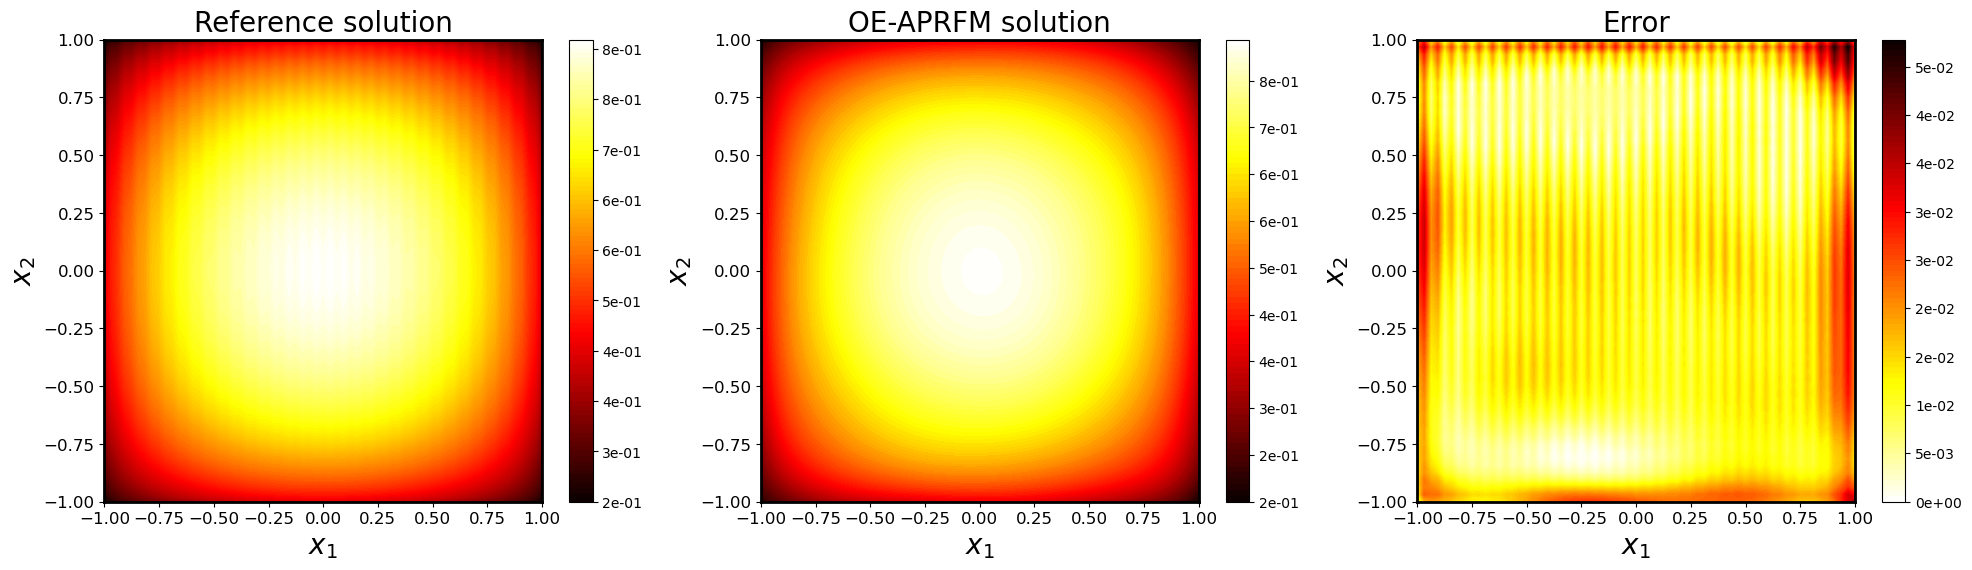

In [25]:
F, F_hat = f_ex, f_approx

font_format = {"size": 20}

plt.figure(figsize=(24, 6))
ax1 = plt.subplot(1, 3, 1)
plt.contourf(X, Y, F, 100, cmap="hot")
# font size and type
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
plt.title("Reference solution", font_format)
# # line width of four axises
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)

ax2 = plt.subplot(1, 3, 2)
plt.contourf(X, Y, F_hat, 100, cmap="hot")
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
plt.title("OE-APRFM solution", font_format)
# # line width of four axises
ax2.spines["bottom"].set_linewidth(2)
ax2.spines["left"].set_linewidth(2)
ax2.spines["right"].set_linewidth(2)
ax2.spines["top"].set_linewidth(2)

ax3 = plt.subplot(1, 3, 3)
plt.contourf(X, Y, np.abs(F - F_hat), 100, cmap="hot_r")
# plt.contourf(X, V, np.abs(F - F_hat), 100, cmap='Spectral_r')
plt.xticks(size=12)
plt.yticks(size=12)
plt.xlabel(r"$x_1$", font_format)
plt.ylabel(r"$x_2$", font_format)
plt.colorbar(format="%.0e")
plt.title("Error", font_format)
# # line width of four axises
ax3.spines["bottom"].set_linewidth(2)
ax3.spines["left"].set_linewidth(2)
ax3.spines["right"].set_linewidth(2)
ax3.spines["top"].set_linewidth(2)
# plt.savefig(f"./figures/aprfm2d_{kn:.1e}_contourf_ex4.png", dpi=300)
plt.show()
plt.close()

In [26]:
jnp.linalg.norm(F_hat - F) / jnp.linalg.norm(F)

Array(0.02315222, dtype=float64)

In [29]:
# # 对比同一“速度变量”：参考解和数值解的 -grad rho
# dx = mesh_x[1] - mesh_x[0]
# dy = mesh_y[1] - mesh_y[0]

# # 参考解 rho = F，数值解 rho_hat = F_hat
# dF_dy, dF_dx = np.gradient(F, dy, dx)
# dFh_dy, dFh_dx = np.gradient(F_hat, dy, dx)

# Vx_ref, Vy_ref = -dF_dx, -dF_dy
# Vx_num, Vy_num = -dFh_dx, -dFh_dy

# # 子采样网格
# ny, nx = X.shape
# step_x = max(1, nx // 16)
# step_y = max(1, ny // 16)

# X_s = X[::step_y, ::step_x]
# Y_s = Y[::step_y, ::step_x]
# Vx_ref_s = Vx_ref[::step_y, ::step_x]
# Vy_ref_s = Vy_ref[::step_y, ::step_x]
# Vx_num_s = Vx_num[::step_y, ::step_x]
# Vy_num_s = Vy_num[::step_y, ::step_x]

# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# plt.quiver(X_s, Y_s, Vx_ref_s, Vy_ref_s)
# plt.xlabel(r"$x_1$")
# plt.ylabel(r"$x_2$")
# # plt.title("Reference -grad rho")
# plt.axis("equal")

# plt.subplot(1, 2, 2)
# plt.quiver(X_s, Y_s, Vx_num_s, Vy_num_s)
# plt.xlabel(r"$x_1$")
# plt.ylabel(r"$x_2$")
# # plt.title("OE-APRFM -grad rho_hat")
# plt.axis("equal")

# plt.tight_layout()
# plt.show()

In [30]:
# # 二维极坐标截面分布示例，修正vmap输入shape问题
# x = jnp.linspace(0, 1, 100)
# th = jnp.linspace(0, jnp.pi, 100)
# X, Th = jnp.meshgrid(x, th, indexing="ij")
# # 保证所有输入shape一致 (10000, 1)
# xv = X.reshape(-1, 1)
# yv = jnp.full_like(xv, -1.0)
# thv = Th.reshape(-1, 1)
# fb_app = vmap(approx_fn, in_axes=(0, 0, 0))(xv, yv, thv)
# fb_app = fb_app.reshape(X.shape)
# fb_ex = jnp.zeros_like(fb_app)

# plt.figure(figsize=(6, 5))
# ax = plt.subplot(111, polar=True)
# ax.plot(th, fb_app[X.shape[0] // 2, :], linewidth=5, label=r"$f(x_0, y_0, \theta)$")
# ax.plot(
#     th,
#     fb_ex[X.shape[0] // 2, :],
#     linewidth=5,
#     label=r"$f_{ex}(x_0, y_0, \theta)$",
#     linestyle="--",
# )
# ax.legend()
# plt.show()

In [ ]:
# # 3D surface plot: Approximation vs Reference
# import matplotlib.pyplot as plt
# from matplotlib import cm
# from matplotlib import rc

# # 定义 plot_3d 辅助函数
# from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


# def plot_3d(ax, Z, colors):
#     nx, ny = Z.shape
#     X, Y = np.meshgrid(np.arange(ny), np.arange(nx))
#     ax.plot_surface(X, Y, Z, facecolors=colors, rstride=1, cstride=1, antialiased=False)


# # 假设 F_hat, F, mesh_x, mesh_y 已经在前面 cell 计算
# rho_approx = F_hat
# rho_ref = F

# # 若 mesh_x, mesh_y 不是等长，则需调整 shape
# rho_approx = np.array(rho_approx)
# rho_ref_grid = np.array(rho_ref)

# print(
#     f"relative error: {np.linalg.norm(rho_approx - rho_ref_grid) / np.linalg.norm(rho_ref_grid)}"
# )

# # Font format for axes labels
# rc("font", family="Times New Roman", size=20)

# # surface plot
# fig = plt.figure(figsize=(16, 8))
# # ------------------ Approximation ------------------
# norm1 = plt.Normalize(rho_approx.min(), rho_approx.max())
# colors1 = cm.viridis(norm1(rho_approx))
# ax1 = fig.add_subplot(121, projection="3d")
# plot_3d(ax1, rho_approx, colors1)
# ax1.set_xlabel(r"$x_1$")
# ax1.set_ylabel(r"$x_2$")
# ax1.set_title(r"Approximation")
# plt.grid()
# # ------------------ Reference ------------------
# norm2 = plt.Normalize(rho_ref_grid.min(), rho_ref_grid.max())
# colors2 = cm.viridis(norm2(rho_ref_grid))
# ax2 = fig.add_subplot(122, projection="3d")
# plot_3d(ax2, rho_ref_grid, colors2)
# ax2.set_xlabel(r"$x_1$")
# ax2.set_ylabel(r"$x_2$")
# ax2.set_title(r"Reference")
# plt.grid()
# # Save and show the figure
# # plt.savefig(f"./rte2d_rho_surface_{kn:.1e}.png", dpi=300)
# plt.show()
# plt.close()

In [32]:
# # 3D surface plot 已完成，以下为等高线对比图
# fig = plt.figure(figsize=(16, 8))

# # ------------------ Approximation ------------------
# ax1 = fig.add_subplot(121)
# contour1 = ax1.contourf(
#     mesh_x, mesh_y, rho_approx, levels=10, alpha=0.8, cmap="viridis"
# )
# ax1.set_xlabel(r"$x_1$")
# ax1.set_ylabel(r"$x_2$")
# ax1.set_title(r"Approximation")
# ax1.set_aspect("equal")
# cbar1 = plt.colorbar(
#     contour1, ax=ax1, shrink=0.65, aspect=20, ticks=[0.2, 0.22, 0.24, 0.26, 0.28, 0.30]
# )
# # ------------------ Reference ------------------
# ax2 = fig.add_subplot(122)

# contour2 = ax2.contourf(
#     mesh_x, mesh_y, rho_ref_grid, levels=10, alpha=0.8, cmap="viridis"
# )
# ax2.set_xlabel(r"$x_1$")
# ax2.set_ylabel(r"$x_2$")
# ax2.set_title(r"Reference")
# ax2.set_aspect("equal")
# cbar2 = plt.colorbar(
#     contour2, ax=ax2, shrink=0.65, aspect=20, ticks=[0.2, 0.22, 0.24, 0.26, 0.28, 0.30]
# )
# plt.tight_layout()
# # Save and show the figure
# # plt.savefig(f"./rte2d_rho_contour_{kn:.1e}.png", dpi=300)
# plt.show()
# plt.close()